In [3]:
import pandas
import matplotlib.pyplot as plt
import hddm
import numpy as np
from pandas import Series
import sys
import os
import seaborn as sns

from kabuki.analyze import check_geweke
from patsy import dmatrix

print(hddm.__version__)
os.getcwd()

0.8.0


/Users/ivar/opt/anaconda3/envs/pyHDDM/lib/python3.6/site-packages/IPython/parallel.py:13: ShimWarning: The `IPython.parallel` package has been deprecated since IPython 4.0. You should import from ipyparallel instead.
  "You should import from ipyparallel instead.", ShimWarning)


'/Users/ivar'

In [4]:
cd='/Users/ivar/Documents/RTrules/'
os.chdir(cd)
data = hddm.load_csv('flanker_clean.csv',delimiter = ',')

In [3]:
data.rename(columns = {'subj_code':'subj_idx'}, inplace = True)
data

,subj_idx,stim_type,response,rt
0,RoqXsdd7kmV0,Incongruent,1,985.0
1,RoqXsdd7kmV0,Congruent,1,658.0
2,RoqXsdd7kmV0,Incongruent,1,618.0
3,RoqXsdd7kmV0,Congruent,1,866.0
4,RoqXsdd7kmV0,Incongruent,1,573.0
...,...,...,...,...
28795,dMIIaYK8fYRA,Congruent,1,585.0
28796,dMIIaYK8fYRA,Congruent,1,515.0
28797,dMIIaYK8fYRA,Incongruent,1,572.0
28798,dMIIaYK8fYRA,Incongruent,1,490.0


In [4]:
# filter
# data.rename(columns = {'subj_code':'subj_idx'}, inplace = True)
data['rt'] = data['rt']/1000
data = data[data['rt'] > 0.2]
data = data[data['rt'] < 3]

In [5]:
#%%
################
# MODEL 1 FLANKER
################
model_name = 'model1flanker'
samples = 5000

# os.mkdir(cd + '/' + model_name)
os.chdir(cd + '/' + model_name)

data['conflict'] = data['stim_type'] == 'Incongruent'                                   
test_model = hddm.HDDMRegressor(data, {"v ~ C(conflict)"},
                                include=('v', 'a', 't'),
                                group_only_regressors=False, keep_regressor_trace=True,
                                p_outlier=.05)

Adding these covariates:
['v_Intercept', 'v_C(conflict)[T.True]']


/Users/ivar/opt/anaconda3/envs/pyHDDM/lib/python3.6/site-packages/scipy/optimize/optimize.py:2116: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)


 [-----------------100%-----------------] 5001 of 5000 complete in 22021.9 secWARNING: Will not save custom link functions.
Plotting t
Plotting a
Plotting v_Intercept
Plotting v_C(conflict)[T.True]


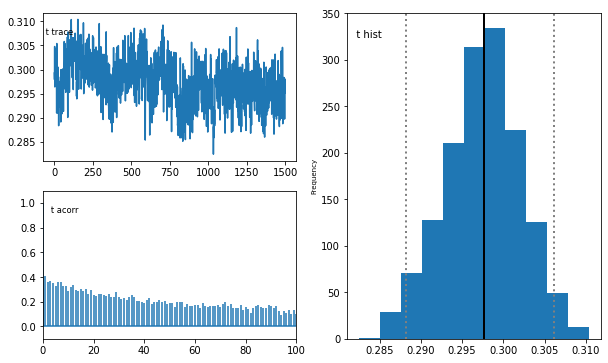

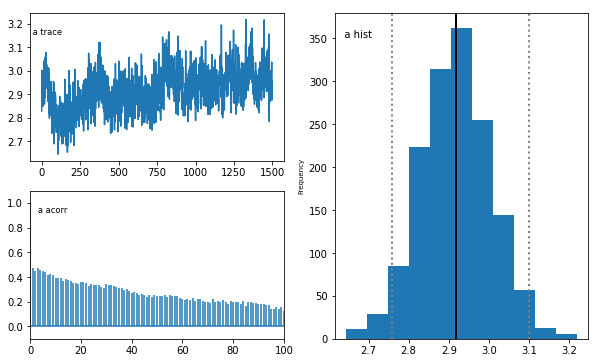

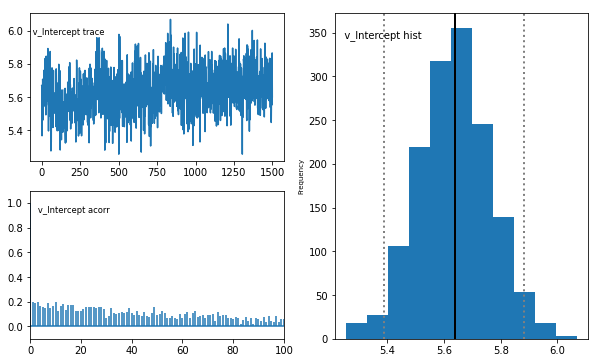

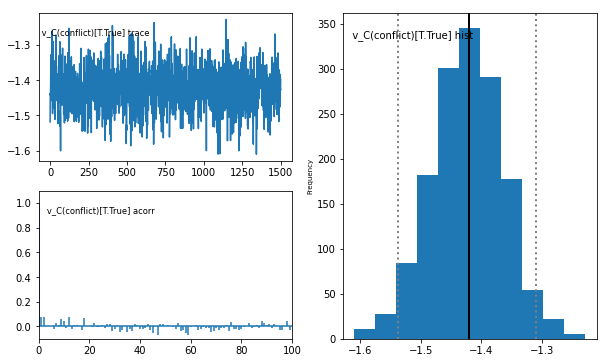

In [6]:
test_model.find_starting_values()
test_model.sample(samples, burn=samples/10, thin=3, dbname=os.path.join(cd, model_name, model_name + '_trace'), db='pickle')
test_model.save(model_name)
test_model.print_stats(model_name + '_dic.txt')
test_model_output = test_model.gen_stats()
test_model_output.to_csv(model_name + '_output.csv')

test_model.plot_posteriors(['t'], save=True)
test_model.plot_posteriors(['a'], save=True)
test_model.plot_posteriors(['v_Intercept'], save=True)
test_model.plot_posteriors(['v_C(conflict)[T.True]'], save=True)
# test_model.plot_posteriors(['z'], save=True)


# get traces to retrieve posterior distributions
test_model = hddm.load(model_name)
results = test_model.get_traces()
results.to_csv(model_name + '_within_traces.csv')


In [7]:
# print DIC
test_model.dic

-39207.483167411054

In [8]:
cd='/Users/ivar/Documents/RTrules/'
os.chdir(cd)

In [9]:
data2 = hddm.load_csv('stroop_clean.csv',delimiter = ',')
data2.rename(columns = {'subj_code':'subj_idx'}, inplace = True)
# filter
data2['rt'] = data2['rt']/1000
data2 = data2[data2['rt'] > 0.2]
data2 = data2[data2['rt'] < 5]


In [10]:
data2['conflict'] = data2['stim_type'] == 'Incongruent'                                   
data2

,subj_idx,stim_type,response,rt,conflict
0,RoqXsdd7kmV0,Congruent,1,1.064,False
1,RoqXsdd7kmV0,Incongruent,1,1.071,True
2,RoqXsdd7kmV0,Congruent,1,0.948,False
3,RoqXsdd7kmV0,Incongruent,1,1.103,True
4,RoqXsdd7kmV0,Congruent,1,0.929,False
...,...,...,...,...,...
28795,dMIIaYK8fYRA,Congruent,1,0.941,False
28796,dMIIaYK8fYRA,Incongruent,1,0.938,True
28797,dMIIaYK8fYRA,Incongruent,1,0.935,True
28798,dMIIaYK8fYRA,Congruent,1,0.740,False


In [11]:
#%%
################
# MODEL 1 STROOP
################
model_name = 'model1stroop'
samples = 5000

# os.mkdir(cd + '/' + model_name)
os.chdir(cd + '/' + model_name)

test_model = hddm.HDDMRegressor(data2, {"v ~ C(conflict)"},
                                include=('v', 'a', 't'),
                                group_only_regressors=False, keep_regressor_trace=True,
                                p_outlier=.05)

Adding these covariates:
['v_Intercept', 'v_C(conflict)[T.True]']


/Users/ivar/opt/anaconda3/envs/pyHDDM/lib/python3.6/site-packages/scipy/optimize/optimize.py:2116: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)


 [-----------------100%-----------------] 5001 of 5000 complete in 16788.0 secWARNING: Will not save custom link functions.
Plotting t
Plotting v_Intercept
Plotting v_C(conflict)[T.True]
Plotting a


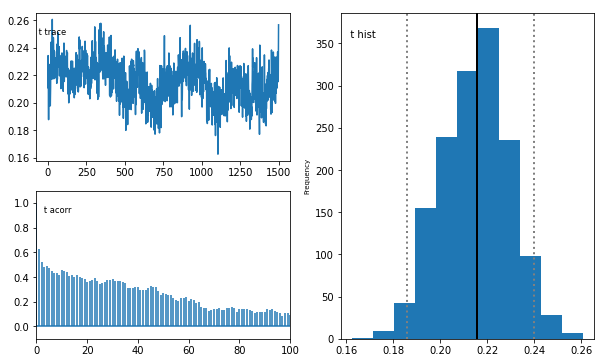

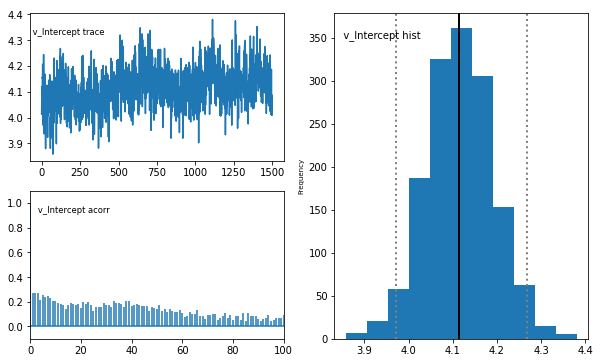

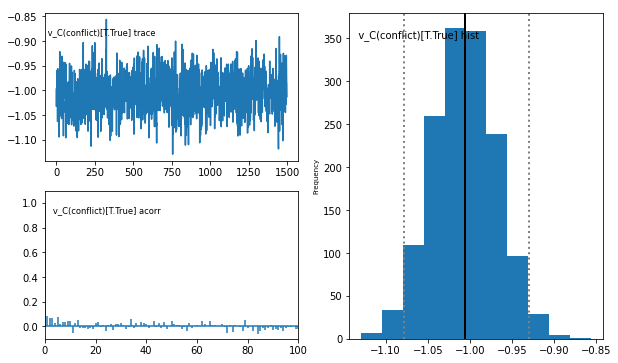

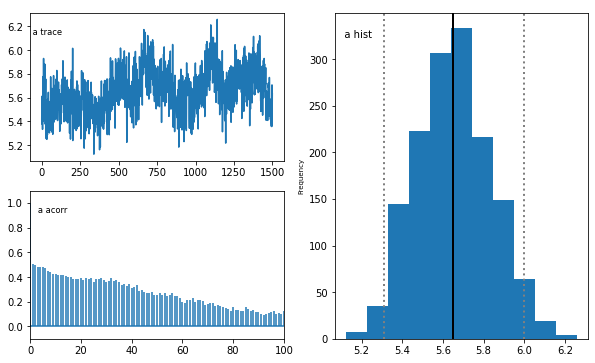

In [12]:
test_model.find_starting_values()
test_model.sample(samples, burn=samples/10, thin=3, dbname=os.path.join(cd, model_name, model_name + '_trace'), db='pickle')
test_model.save(model_name)
test_model.print_stats(model_name + '_dic.txt')
test_model_output = test_model.gen_stats()
test_model_output.to_csv(model_name + '_output.csv')

test_model.plot_posteriors(['t'], save=True)
test_model.plot_posteriors(['v_Intercept'], save=True)
test_model.plot_posteriors(['v_C(conflict)[T.True]'], save=True)
test_model.plot_posteriors(['a'], save=True)
# test_model.plot_posteriors(['z'], save=True)


# get traces to retrieve posterior distributions
test_model = hddm.load(model_name)
results = test_model.get_traces()
results.to_csv(model_name + '_within_traces.csv')


In [20]:
# print DIC
test_model.dic

2364.3566999387604

Plotting v_Intercept
Plotting v_C(conflict)[T.True]


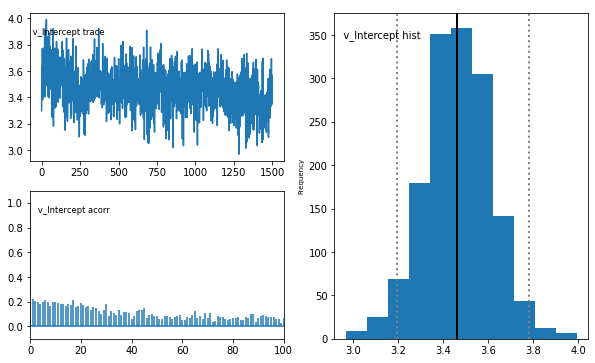

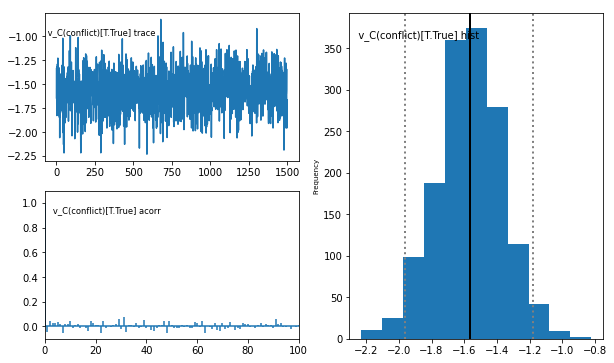

In [21]:
test_model.plot_posteriors(['v_Intercept'], save=True)
test_model.plot_posteriors(['v_C(conflict)[T.True]'], save=True)

In [75]:
#%%
################
# MODEL 1
################
model_name = 'model1stroop'
samples = 5000

# os.mkdir(cd + '/' + model_name)
os.chdir(cd + '/' + model_name)
                                
test_model = hddm.HDDMRegressor(data2,
                                   {"v ~ C(conflict)"},
                                   p_outlier=.05)

Adding these covariates:
['v_Intercept', 'v_C(conflict)[T.True]']


/Users/ivar/opt/anaconda3/envs/pyHDDM/lib/python3.6/site-packages/scipy/optimize/optimize.py:2116: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)


 [-----------------100%-----------------] 5001 of 5000 complete in 3301.3 secWARNING: Will not save custom link functions.
Plotting t
Plotting a
Plotting v_Intercept
Plotting v_C(conflict)[T.True]


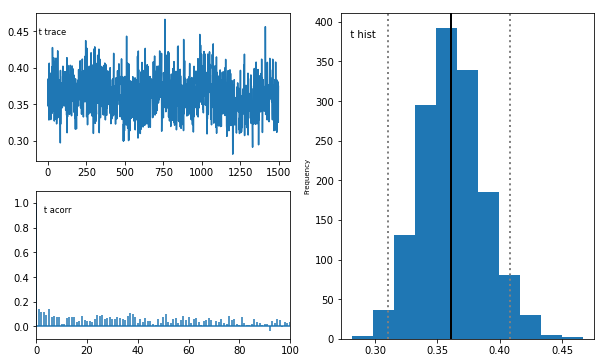

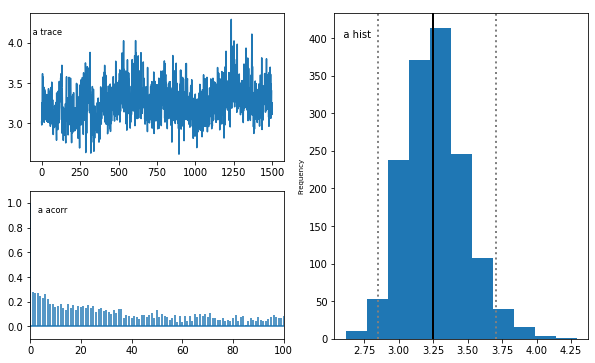

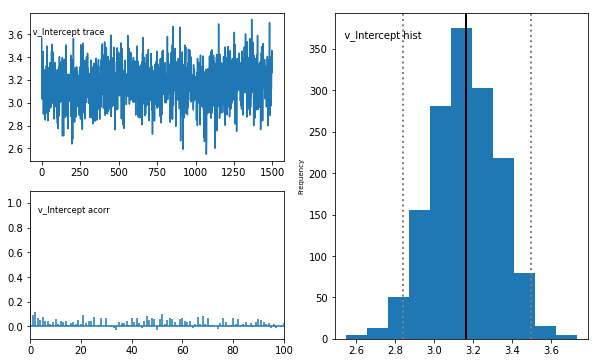

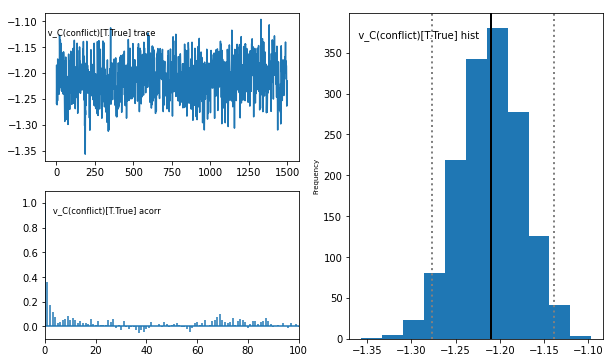

In [76]:
test_model.find_starting_values()
test_model.sample(samples, burn=samples/10, thin=3, dbname=os.path.join(cd, model_name, model_name + '_trace'), db='pickle')
test_model.save(model_name)
test_model.print_stats(model_name + '_dic.txt')
test_model_output = test_model.gen_stats()
test_model_output.to_csv(model_name + '_output.csv')

test_model.plot_posteriors(['t'], save=True)
test_model.plot_posteriors(['a'], save=True)
test_model.plot_posteriors(['v_Intercept'], save=True)
test_model.plot_posteriors(['v_C(conflict)[T.True]'], save=True)
# test_model.plot_posteriors(['z'], save=True)


# get traces to retrieve posterior distributions
test_model = hddm.load(model_name)
results = test_model.get_traces()
results.to_csv(model_name + '_within_traces.csv')


In [16]:
cd='/Users/ivar/Documents/RTrules/'
os.chdir(cd)

data = hddm.load_csv('rules_clean.csv',delimiter = ',')
data.rename(columns = {'subj_code':'subj_idx'}, inplace = True)
# filter
data['rt'] = data['rt']/1000
data = data[data['rt'] > 0.5]
data = data[data['rt'] < 8]

In [16]:
#%%
################
# MODEL 1
################
model_name = 'model1rulesFS'
samples = 5000

# os.mkdir(cd + '/' + model_name)
os.chdir(cd + '/' + model_name)

test_model = hddm.HDDM(data, include=('v', 'a', 't', 'z'),  
                      depends_on={'v': ['text', 'purpose']}, 
                      p_outlier=.05)
                                   

/Users/ivar/opt/anaconda3/envs/pyHDDM/lib/python3.6/site-packages/scipy/optimize/optimize.py:2116: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)


 [-----------------100%-----------------] 5001 of 5000 complete in 6672.5 secPlotting t
Plotting v(0.0)
Plotting v(0.1)
Plotting v(1.0)
Plotting v(1.1)
Plotting a


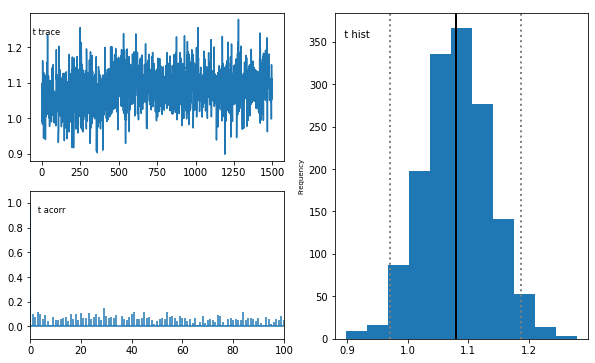

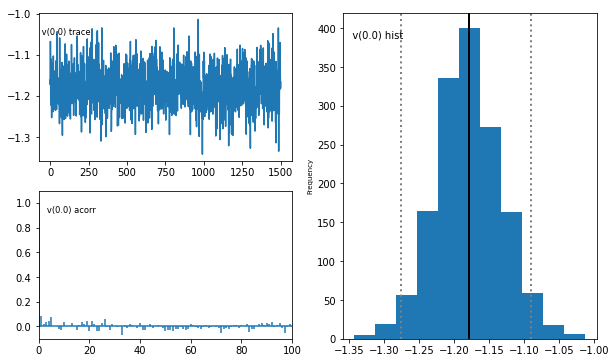

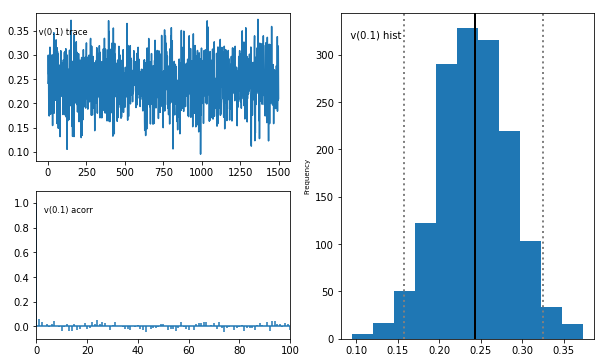

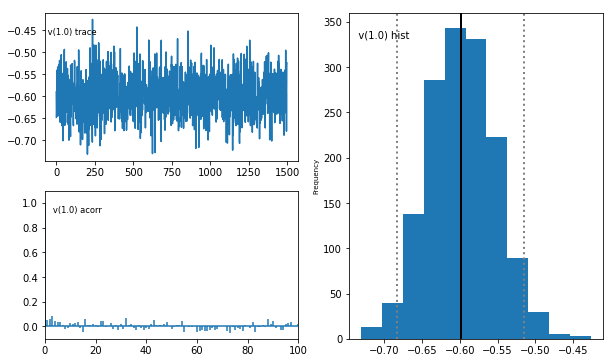

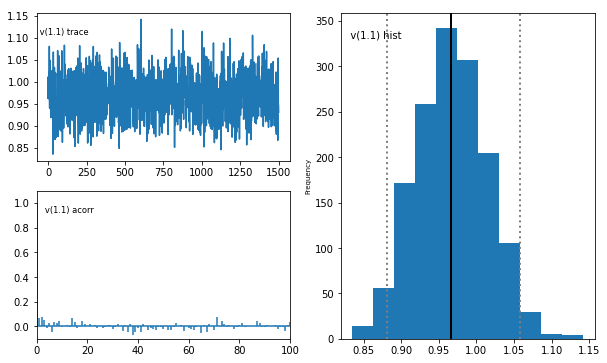

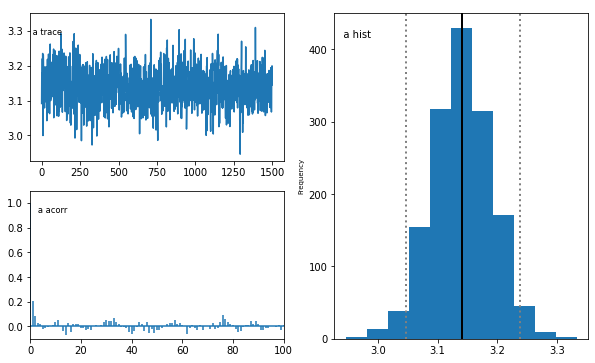

In [17]:
test_model.find_starting_values()
test_model.sample(samples, burn=samples/10, thin=3, dbname=os.path.join(cd, model_name, model_name + '_trace'), db='pickle')
test_model.save(model_name)
test_model.print_stats(model_name + '_dic.txt')
test_model_output = test_model.gen_stats()
test_model_output.to_csv(model_name + '_output.csv')

test_model.plot_posteriors(['t'], save=True)
test_model.plot_posteriors(['v'], save=True)
test_model.plot_posteriors(['a'], save=True)
# test_model.plot_posteriors(['z'], save=True)


# get traces to retrieve posterior distributions
test_model = hddm.load(model_name)
results = test_model.get_traces()
results.to_csv(model_name + '_within_traces.csv')


In [17]:
data['congruent'] = data['text'] == data['purpose']

In [20]:
data['conflict'] = data['text'] != data['purpose']

In [18]:
data['response2'] = data['response'] 
# Conditionally update response column based on text and response2 columns
data.loc[data['text'] == data['response2'], 'response'] = 1
data.loc[data['text'] != data['response2'], 'response'] = 0
data

,subj_idx,trial_index,text,purpose,congruent,response,rt,rule,endorsement,bipolar,response2
0,RoqXsdd7kmV0,84,0,1,False,1.0,6.070,drink,p_theory,5,0.0
1,RoqXsdd7kmV0,86,1,0,False,1.0,2.378,drink,p_theory,5,1.0
2,RoqXsdd7kmV0,88,1,0,False,1.0,6.988,drink,p_theory,5,1.0
3,RoqXsdd7kmV0,90,1,0,False,1.0,3.478,drink,p_theory,5,1.0
4,RoqXsdd7kmV0,92,0,0,True,1.0,2.362,drink,p_theory,5,0.0
...,...,...,...,...,...,...,...,...,...,...,...
28795,dMIIaYK8fYRA,574,1,1,True,1.0,2.038,shoot,p_theory,1,1.0
28796,dMIIaYK8fYRA,576,1,1,True,1.0,1.399,shoot,p_theory,1,1.0
28797,dMIIaYK8fYRA,578,0,1,False,1.0,2.049,shoot,p_theory,1,0.0
28798,dMIIaYK8fYRA,580,0,1,False,1.0,1.468,shoot,p_theory,1,0.0


In [21]:
#%%
################
# MODEL 2
################
model_name = 'model2rulesFS'
samples = 5000

# os.mkdir(cd + '/' + model_name)
os.chdir(cd + '/' + model_name)

test_model = hddm.HDDMRegressor(data,
                                   {"v ~ C(conflict)"},
                                include=('v', 'a', 't', 'z'),
                                group_only_regressors=False, keep_regressor_trace=True,
                                   p_outlier=.05)
                                   

Adding these covariates:
['v_Intercept', 'v_C(conflict)[T.True]']


/Users/ivar/opt/anaconda3/envs/pyHDDM/lib/python3.6/site-packages/scipy/optimize/optimize.py:2116: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)


 [-----------------100%-----------------] 5001 of 5000 complete in 19174.6 secWARNING: Will not save custom link functions.
Plotting t
Plotting v_Intercept
Plotting v_C(conflict)[T.True]
Plotting a
Plotting z


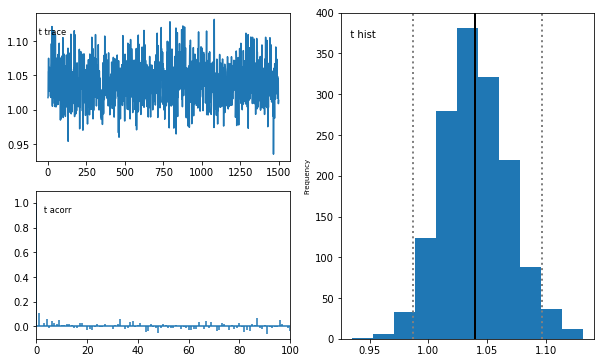

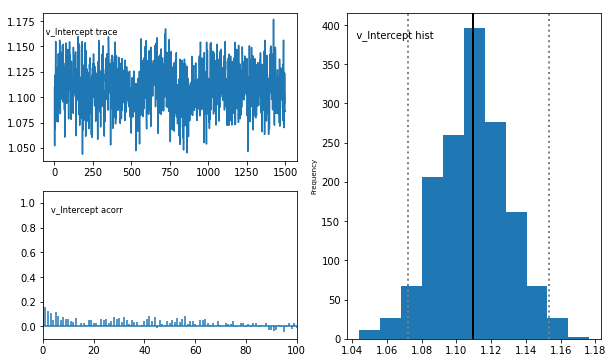

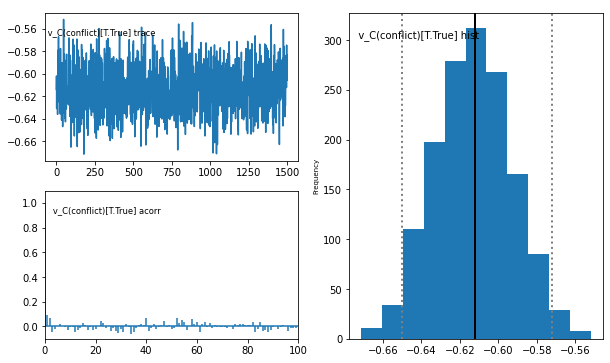

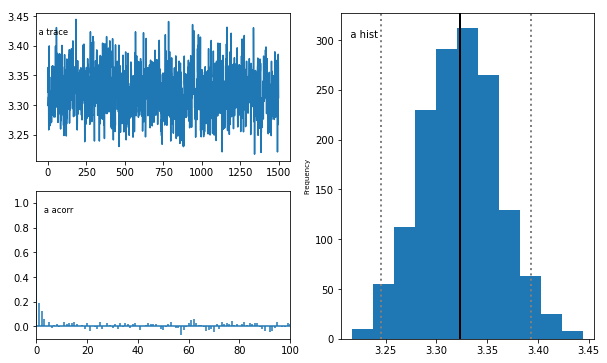

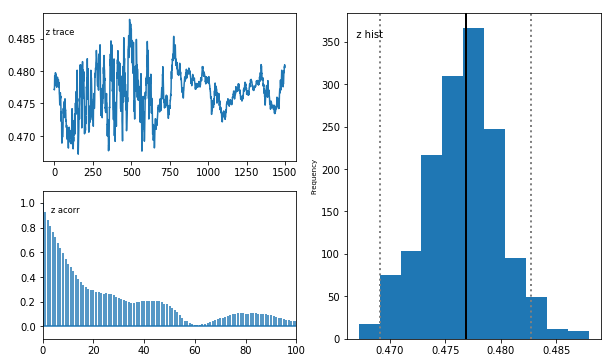

In [22]:
test_model.find_starting_values()
test_model.sample(samples, burn=samples/10, thin=3, dbname=os.path.join(cd, model_name, model_name + '_trace'), db='pickle')
test_model.save(model_name)
test_model.print_stats(model_name + '_dic.txt')
test_model_output = test_model.gen_stats()
test_model_output.to_csv(model_name + '_output.csv')

test_model.plot_posteriors(['t'], save=True)
test_model.plot_posteriors(['v_Intercept'], save=True)
test_model.plot_posteriors(['v_C(conflict)[T.True]'], save=True)
test_model.plot_posteriors(['a'], save=True)
test_model.plot_posteriors(['z'], save=True)


# get traces to retrieve posterior distributions
test_model = hddm.load(model_name)
results = test_model.get_traces()
results.to_csv(model_name + '_within_traces.csv')


In [27]:
data['conflict'] = data['text'] != data['purpose']
data['violation'] = data['response'] 
# Conditionally replace response column based on text and violation columns
data.loc[data['text'] == data['violation'], 'response'] = 1
data.loc[data['text'] != data['violation'], 'response'] = 0
data

,subj_idx,text,purpose,response,rt,rule,conflict,violation
1,uxHhEDdcx96G,0,0,1.0,3.769,drink,False,0.0
2,uxHhEDdcx96G,0,1,0.0,4.363,drink,True,1.0
3,uxHhEDdcx96G,1,1,1.0,4.101,drink,False,1.0
4,uxHhEDdcx96G,1,0,0.0,4.685,drink,True,0.0
5,uxHhEDdcx96G,0,1,0.0,4.229,drink,True,1.0
...,...,...,...,...,...,...,...,...
7265,pmFs7MfKf2zJ,1,1,1.0,1.211,cars,False,1.0
7266,pmFs7MfKf2zJ,0,0,1.0,1.126,cars,False,0.0
7267,pmFs7MfKf2zJ,1,0,1.0,0.957,cars,True,1.0
7268,pmFs7MfKf2zJ,0,1,0.0,1.570,cars,True,1.0


In [28]:
#%%
################
# MODEL 2
################
model_name = 'model3rulesFS'
samples = 5000

# os.mkdir(cd + '/' + model_name)
os.chdir(cd + '/' + model_name)

test_model = hddm.HDDMRegressor(data,
                                   {"v ~ C(conflict) * C(text)"},
                                include=('v', 'a', 't'),
                                group_only_regressors=False, keep_regressor_trace=True,
                                   p_outlier=.05)

## vInt (c = F, t = 0) off
## v( C = T, t = 0) under
## v(c = F, t = 1) core
## v(c = T, t = 1) over
                                   

Adding these covariates:
['v_Intercept', 'v_C(conflict)[T.True]', 'v_C(text)[T.1]', 'v_C(conflict)[T.True]:C(text)[T.1]']


/Users/ivar/opt/anaconda3/envs/pyHDDM/lib/python3.6/site-packages/scipy/optimize/optimize.py:2116: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)


 [-----------------100%-----------------] 5001 of 5000 complete in 13104.1 secWARNING: Will not save custom link functions.
Plotting t
Plotting a
Plotting z
Plotting v_Intercept
Plotting v_C(conflict)[T.True]
Plotting v_C(text)[T.1]
Plotting v_C(conflict)[T.True]:C(text)[T.1]


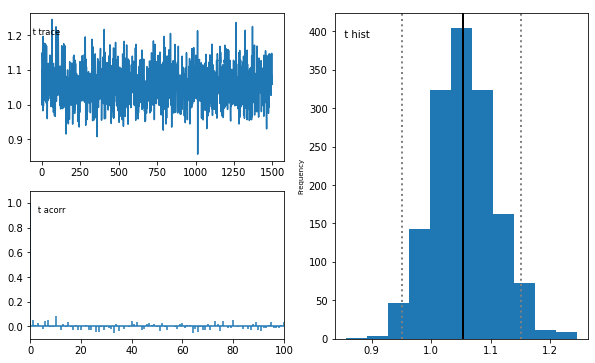

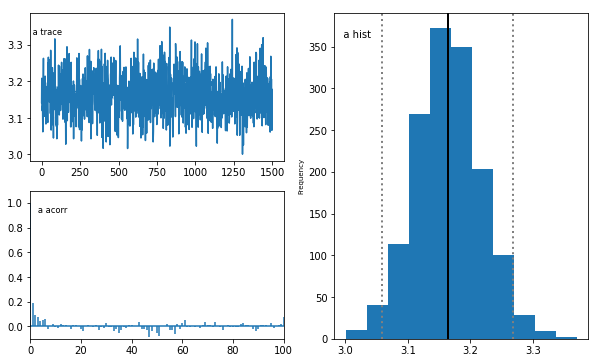

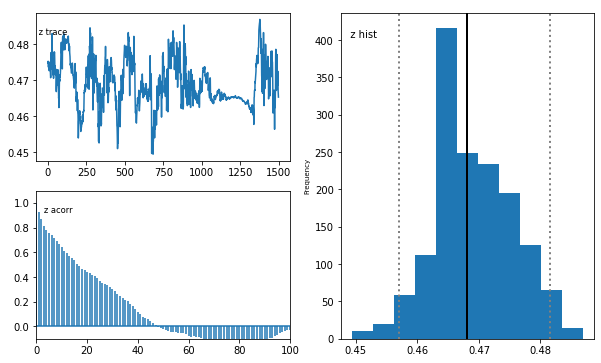

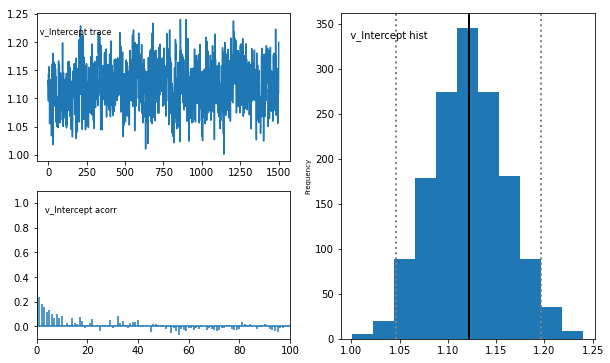

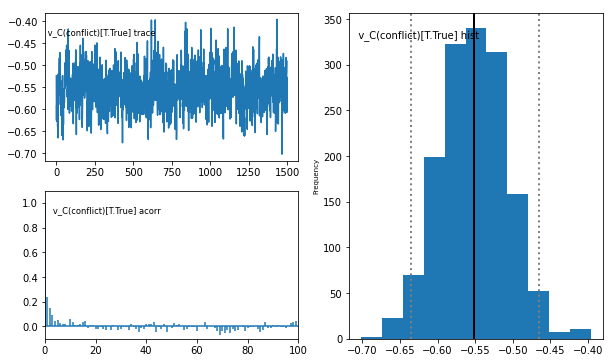

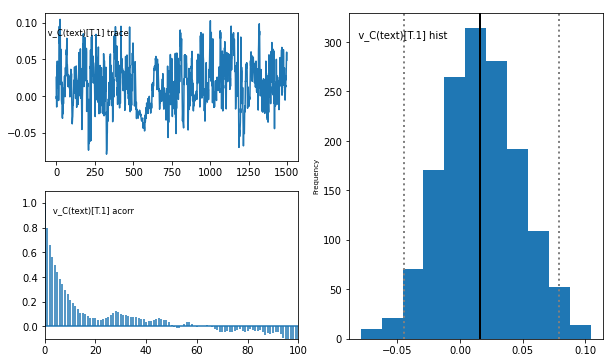

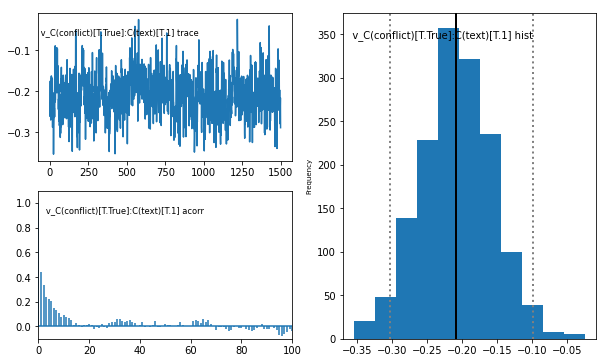

In [29]:
test_model.find_starting_values()
test_model.sample(samples, burn=samples/10, thin=3, dbname=os.path.join(cd, model_name, model_name + '_trace'), db='pickle')
test_model.save(model_name)
test_model.print_stats(model_name + '_dic.txt')
test_model_output = test_model.gen_stats()
test_model_output.to_csv(model_name + '_output.csv')

test_model.plot_posteriors(['t'], save=True)
test_model.plot_posteriors(['a'], save=True)
test_model.plot_posteriors(['z'], save=True)
test_model.plot_posteriors(['v_Intercept'], save=True)
test_model.plot_posteriors(['v_C(conflict)[T.True]'], save=True)
test_model.plot_posteriors(['v_C(text)[T.1]'], save=True)
test_model.plot_posteriors(['v_C(conflict)[T.True]:C(text)[T.1]'], save=True)


# get traces to retrieve posterior distributions
test_model = hddm.load(model_name)
results = test_model.get_traces()
results.to_csv(model_name + '_within_traces.csv')


Plotting v_Intercept
Plotting v_C(conflict)[T.True]
Plotting v_C(text)[T.1]
Plotting v_C(conflict)[T.True]:C(text)[T.1]


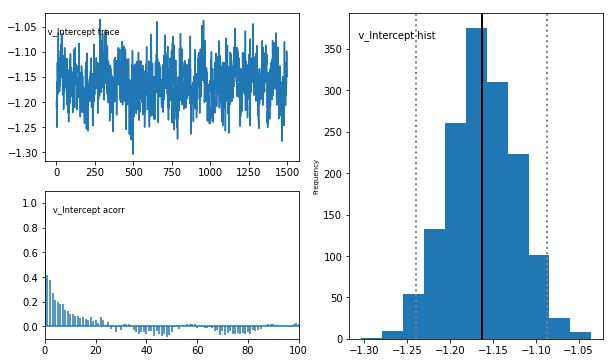

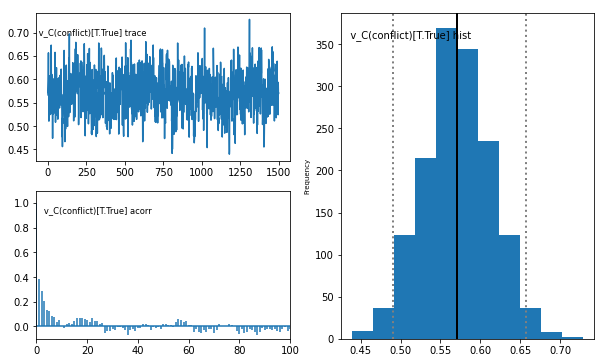

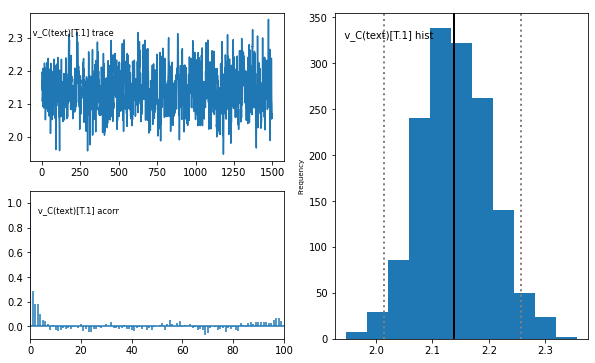

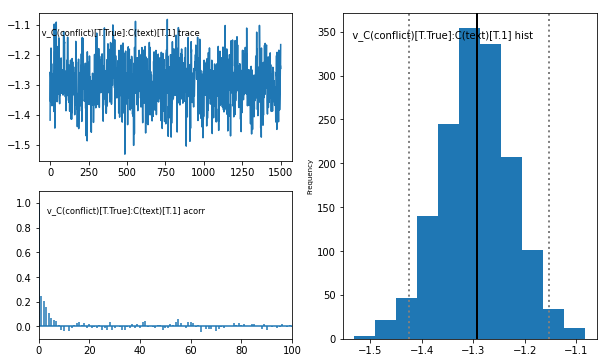

In [41]:
params = {'a': 2, 't': .4, 'z': .5, 'sv': 0, 'sz': 0, 'st': 0}
dfs = []
for v in [0.2, 0.5, 0.6, 0.7]:
    params['v'] = v
    _df, _ = hddm.generate.gen_rand_data(params=params, size=100, subjs=6)
    _df['x'] = v * 2
    dfs.append(_df)
df = pandas.concat(dfs)
model = hddm.HDDMRegressor(df,'v ~ x')
model.sample(10, 1)
model.plot_posterior_predictive()
plt.savefig('plot_posterior_predictive.png') # see attached file
plt.show() # adding this doesn't matter

Adding these covariates:
['v_Intercept', 'v_x']
 [-----------------100%-----------------] 10 of 10 complete in 3.4 sec

<Figure size 576x432 with 0 Axes>

In [42]:
model

In [43]:
model.plot_posterior_predictive()

<Figure size 576x432 with 0 Axes>

In [5]:
cd='/Users/ivar/Documents/RTrules/'
os.chdir(cd)
data = hddm.load_csv('flanker_clean.csv',delimiter = ',')

In [6]:
# filter
data.rename(columns = {'subj_code':'subj_idx'}, inplace = True)
data['rt'] = data['rt']/1000
data = data[data['rt'] > 0.2]
data = data[data['rt'] < 3]

In [13]:
summary = data.groupby(['stim_type']).agg(
    mean_rt=('rt', 'median'),
    mean_accuracy=('response', 'mean')
).reset_index()

print(summary)

     stim_type  mean_rt  mean_accuracy
0    Congruent    0.528       0.981374
1  Incongruent    0.589       0.928485


In [14]:
#data.loc[data['correct'] == True, 'response'] = 1
#data.loc[data['correct'] == False, 'response'] = 0

print(data['subj_idx'].nunique())

300


,subj_idx,stim_type,response,rt
0,RoqXsdd7kmV0,Incongruent,1,0.985
1,RoqXsdd7kmV0,Congruent,1,0.658
2,RoqXsdd7kmV0,Incongruent,1,0.618
3,RoqXsdd7kmV0,Congruent,1,0.866
4,RoqXsdd7kmV0,Incongruent,1,0.573
...,...,...,...,...
28795,dMIIaYK8fYRA,Congruent,1,0.585
28796,dMIIaYK8fYRA,Congruent,1,0.515
28797,dMIIaYK8fYRA,Incongruent,1,0.572
28798,dMIIaYK8fYRA,Incongruent,1,0.490


In [15]:
#%%
################
# MODEL 1 FLANKER
################
model_name = 'model2flanker'
samples = 5000

# os.mkdir(cd + '/' + model_name)
os.chdir(cd + '/' + model_name)

data['conflict'] = data['flanker_stim_type'] == 'incongruent'                                   
test_model = hddm.HDDM(data, include=('v', 'a', 't'), p_outlier=.05,
                       depends_on={'v': ['conflict', 'block'],
                                   't': ['block'],
                                   'a': ['block']})

KeyError: 'flanker_stim_type'

/Users/ivar/opt/anaconda3/envs/pyHDDM/lib/python3.6/site-packages/scipy/optimize/optimize.py:2116: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)


 [-----------------100%-----------------] 3001 of 3000 complete in 4059.6 secPlotting t(1)
Plotting t(2)
Plotting t(3)
Plotting t(4)
Plotting v(1.False)
Plotting v(1.True)
Plotting v(2.False)
Plotting v(2.True)
Plotting v(3.False)
Plotting v(3.True)
Plotting v(4.False)
Plotting v(4.True)
Plotting a(1)
Plotting a(2)
Plotting a(3)
Plotting a(4)


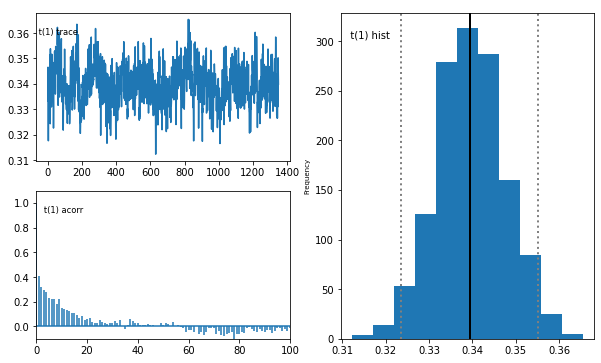

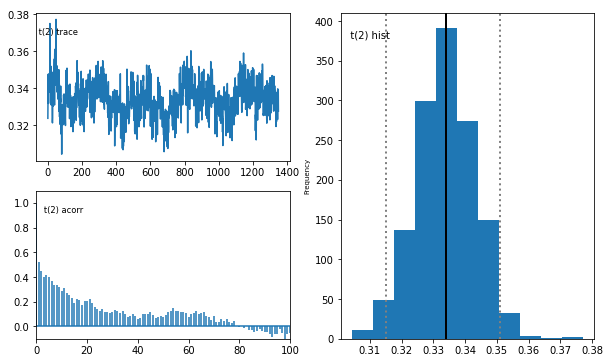

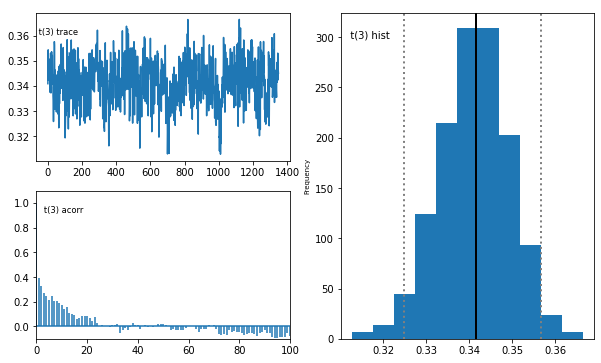

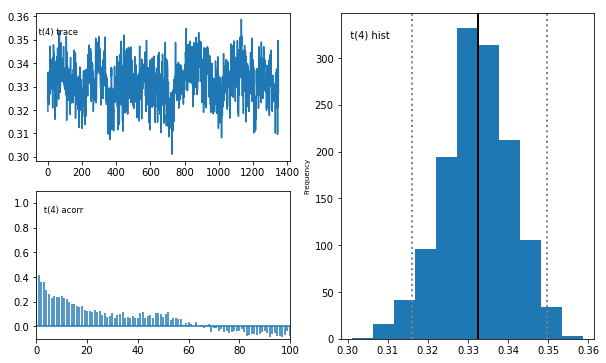

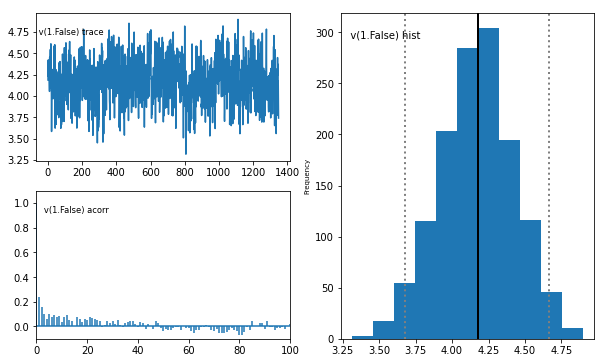

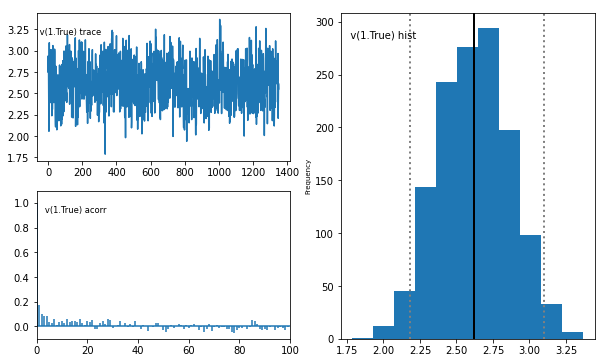

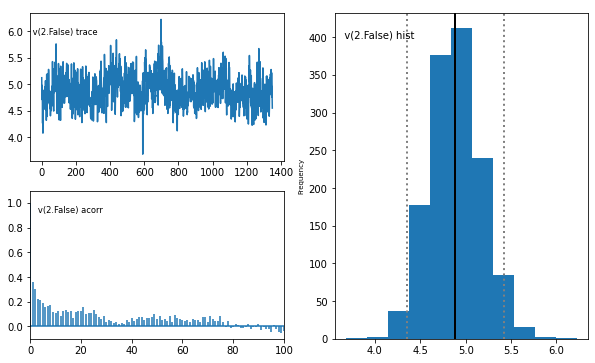

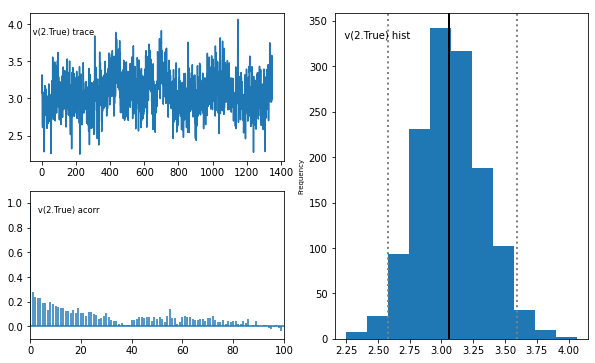

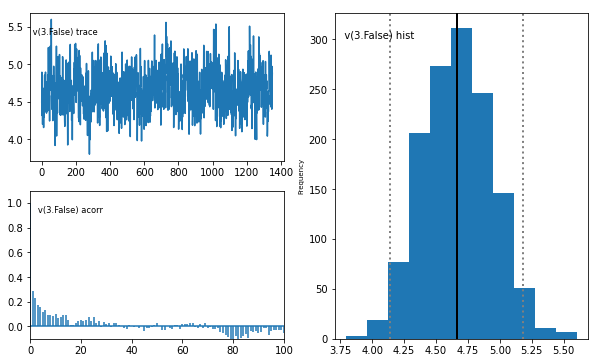

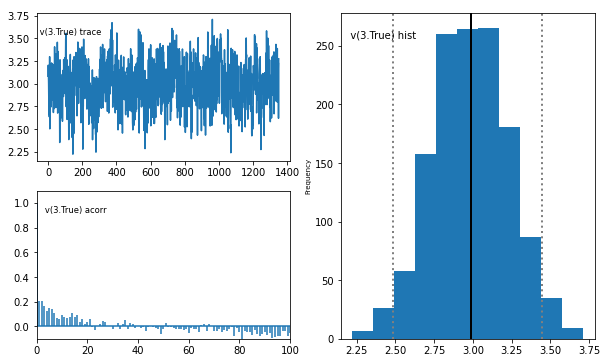

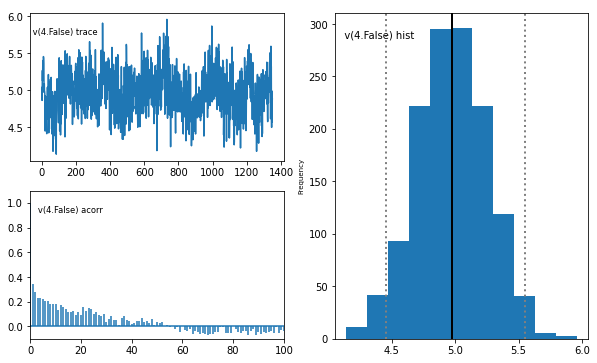

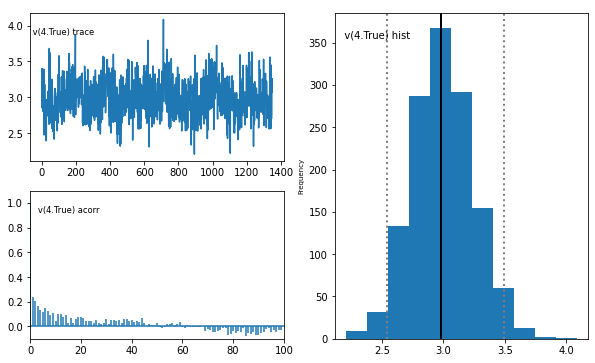

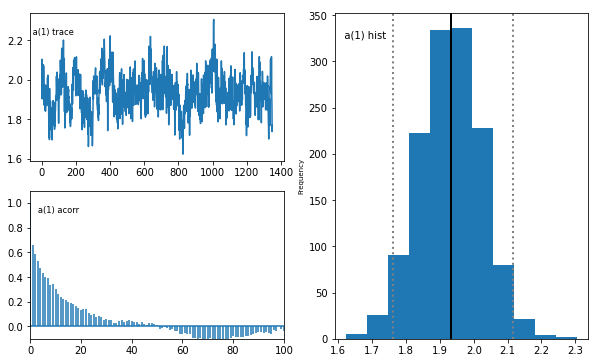

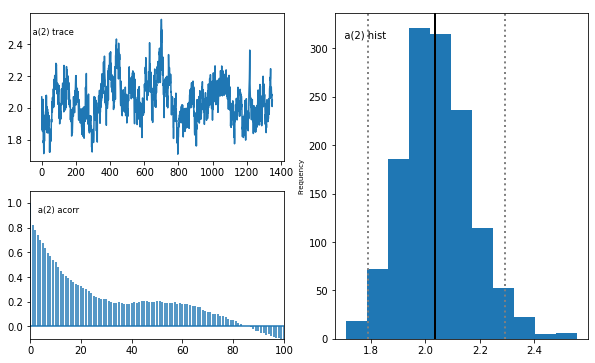

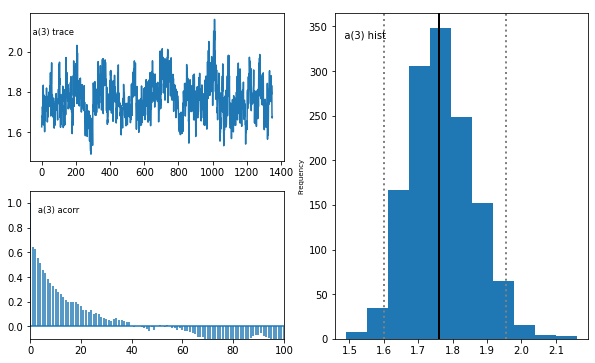

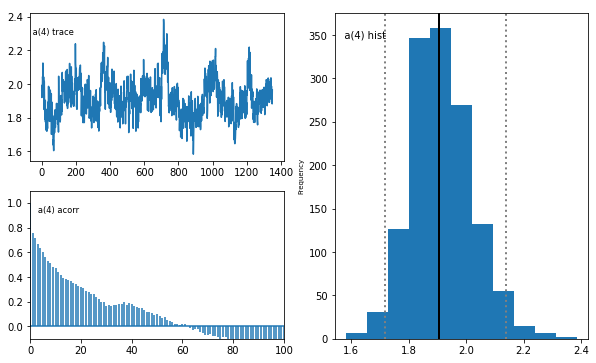

In [47]:
test_model.find_starting_values()
test_model.sample(samples, burn=samples/10, thin=2, dbname=os.path.join(cd, model_name, model_name + '_trace'), db='pickle')
test_model.save(model_name)
test_model.print_stats(model_name + '_dic.txt')
test_model_output = test_model.gen_stats()
test_model_output.to_csv(model_name + '_output.csv')

test_model.plot_posteriors(['t'], save=True)
test_model.plot_posteriors(['v'], save=True)
test_model.plot_posteriors(['a'], save=True)
# test_model.plot_posteriors(['z'], save=True)


# get traces to retrieve posterior distributions
test_model = hddm.load(model_name)
results = test_model.get_traces()
results.to_csv(model_name + '_within_traces.csv')


In [57]:
cd='/Users/ivar/Documents/RTrules/'
os.chdir(cd)
data2 = hddm.load_csv('stroop_clean.csv',delimiter = ',')
data2.rename(columns = {'subj_code':'subj_idx'}, inplace = True)
# filter
data2['rt'] = data2['rt']/1000
data2 = data2[data2['rt'] > 0.2]
data2 = data2[data2['rt'] < 5] 
data2['conflict'] = data2['congruent'] == False   
data2.loc[data2['correct'] == True, 'response'] = 1
data2.loc[data2['correct'] == False, 'response'] = 0   
data2


,subj_idx,congruent,correct,rt,trial_index,block,conflict,response
0,uxHhEDdcx96G,False,False,0.561,257,1,True,0.0
1,uxHhEDdcx96G,True,True,1.103,259,1,False,1.0
2,uxHhEDdcx96G,False,False,0.857,261,1,True,0.0
3,uxHhEDdcx96G,True,True,0.905,263,1,False,1.0
4,uxHhEDdcx96G,False,False,0.885,265,1,True,0.0
...,...,...,...,...,...,...,...,...
7266,pmFs7MfKf2zJ,True,True,0.593,574,4,False,1.0
7267,pmFs7MfKf2zJ,False,True,0.452,576,4,True,1.0
7268,pmFs7MfKf2zJ,False,True,0.518,578,4,True,1.0
7269,pmFs7MfKf2zJ,True,True,0.662,580,4,False,1.0


In [58]:
#%%
################
# MODEL 1 FLANKER
################
model_name = 'model2stroop'
samples = 3000

# os.mkdir(cd + '/' + model_name)
os.chdir(cd + '/' + model_name)
                                  
test_model = hddm.HDDM(data2, include=('v', 'a', 't'), p_outlier=.05,
                       depends_on={'v': ['conflict', 'block'],
                                   't': ['block'],
                                   'a': ['block']})

/Users/ivar/opt/anaconda3/envs/pyHDDM/lib/python3.6/site-packages/scipy/optimize/optimize.py:2116: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)


 [-----------------100%-----------------] 3001 of 3000 complete in 4954.1 secPlotting t(1)
Plotting t(2)
Plotting t(3)
Plotting t(4)
Plotting v(1.False)
Plotting v(1.True)
Plotting v(2.False)
Plotting v(2.True)
Plotting v(3.False)
Plotting v(3.True)
Plotting v(4.False)
Plotting v(4.True)
Plotting a(1)
Plotting a(2)
Plotting a(3)
Plotting a(4)


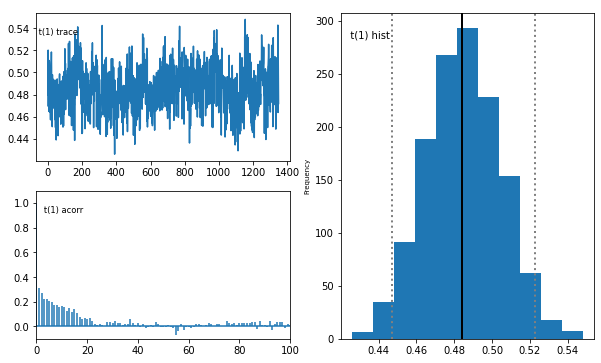

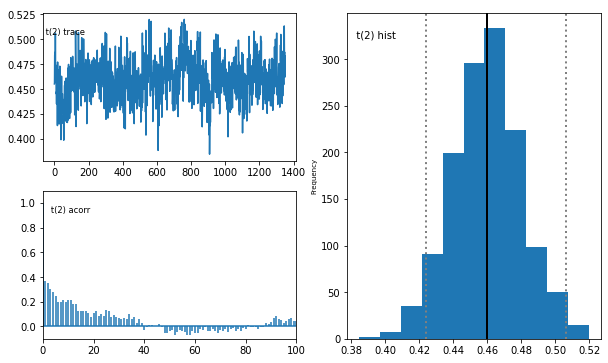

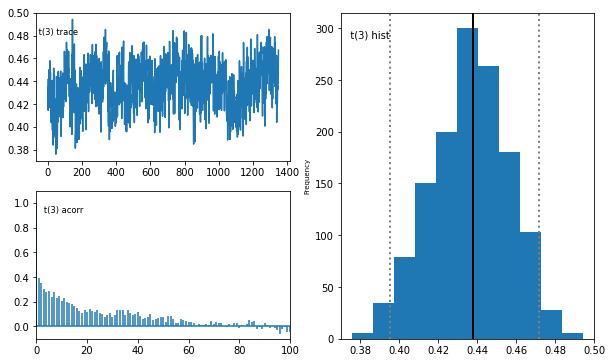

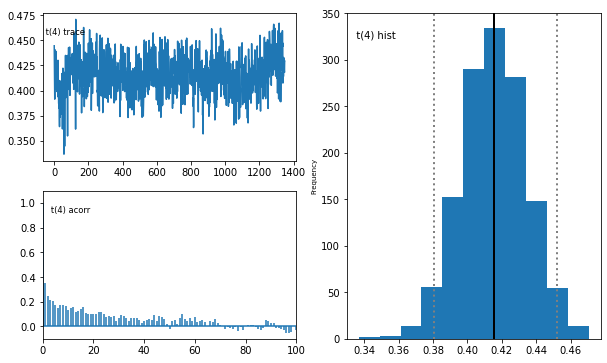

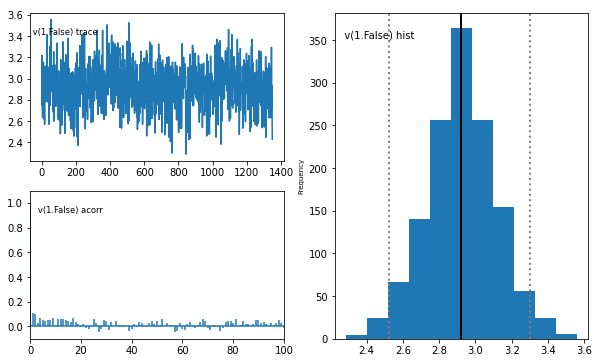

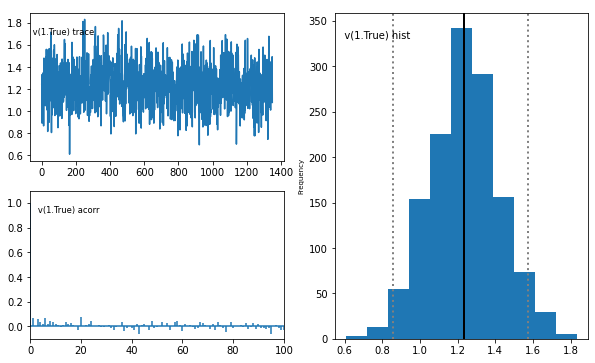

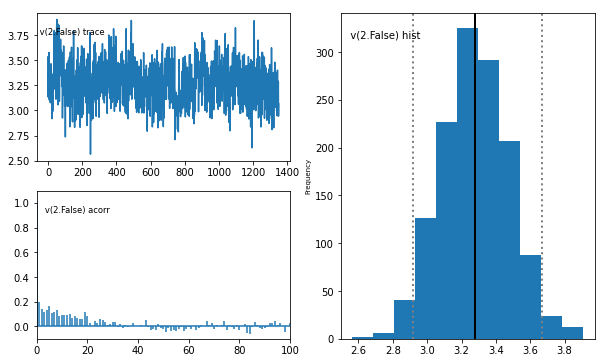

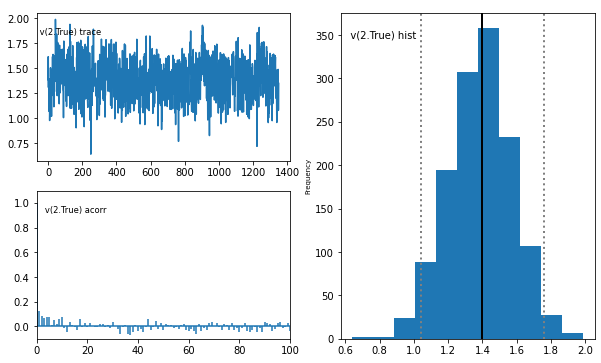

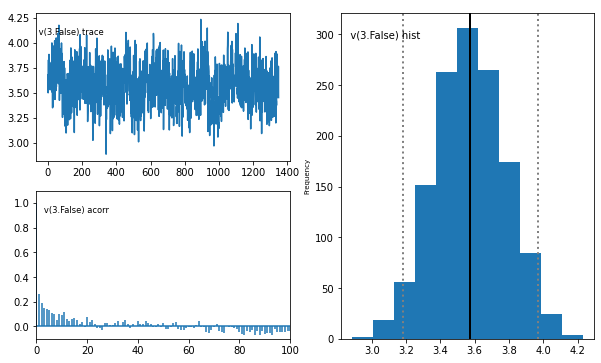

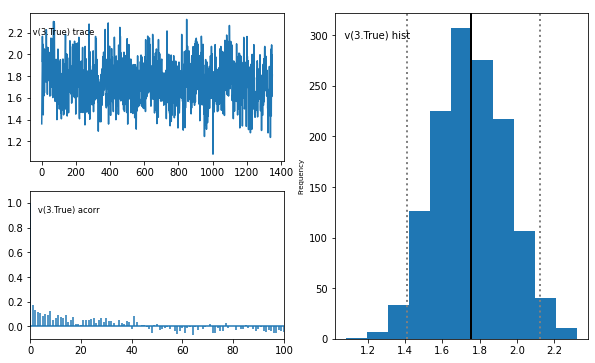

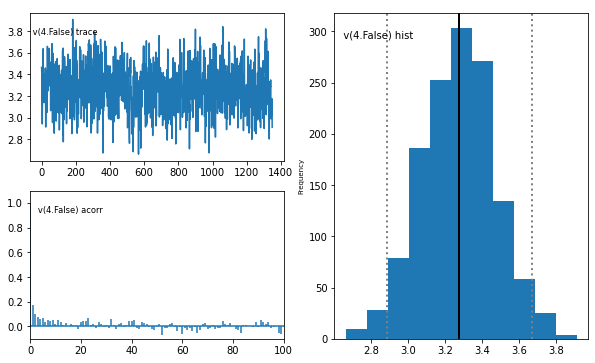

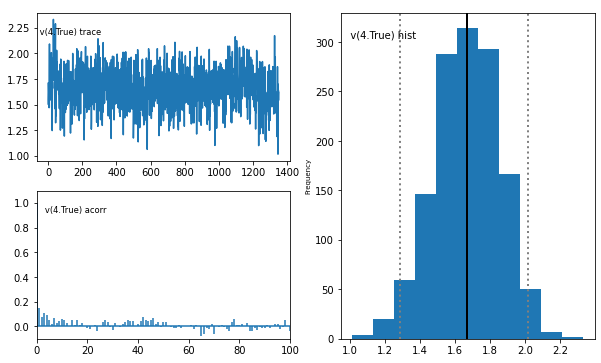

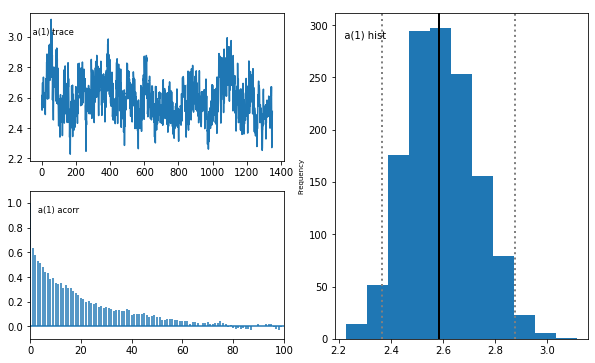

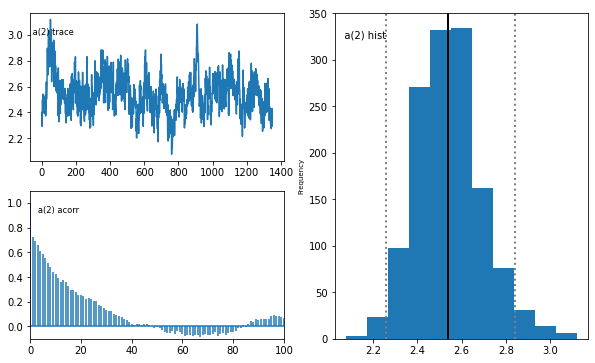

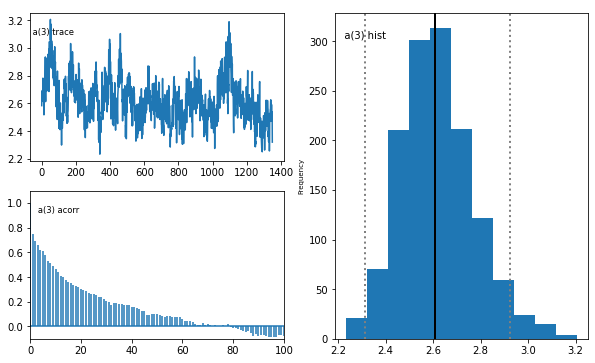

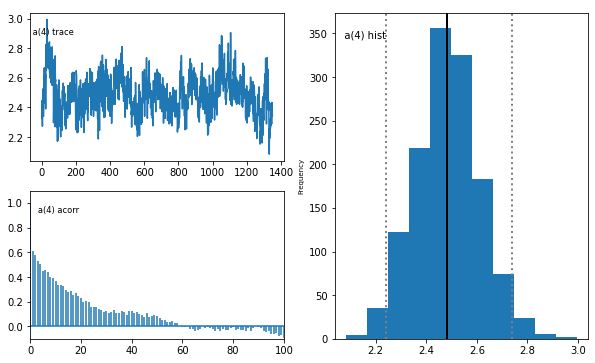

In [59]:
test_model.find_starting_values()
test_model.sample(samples, burn=samples/10, thin=2, dbname=os.path.join(cd, model_name, model_name + '_trace'), db='pickle')
test_model.save(model_name)
test_model.print_stats(model_name + '_dic.txt')
test_model_output = test_model.gen_stats()
test_model_output.to_csv(model_name + '_output.csv')

test_model.plot_posteriors(['t'], save=True)
test_model.plot_posteriors(['v'], save=True)
test_model.plot_posteriors(['a'], save=True)
# test_model.plot_posteriors(['z'], save=True)


# get traces to retrieve posterior distributions
test_model = hddm.load(model_name)
results = test_model.get_traces()
results.to_csv(model_name + '_within_traces.csv')


In [71]:
cd='/Users/ivar/Documents/RTrules/'
os.chdir(cd)

data = hddm.load_csv('rules_cleanFS.csv',delimiter = ',')
data.rename(columns = {'subj_code':'subj_idx'}, inplace = True)
# filter
data['rt'] = data['rt']/1000
data = data[data['rt'] > 0.4]
data = data[data['rt'] < 6]
data

,subj_idx,trial_index,text,purpose,congruent,response,rt,rule,block
1,uxHhEDdcx96G,84,0,0,True,0.0,3.769,drink,1
2,uxHhEDdcx96G,86,0,1,False,1.0,4.363,drink,1
3,uxHhEDdcx96G,88,1,1,True,1.0,4.101,drink,1
4,uxHhEDdcx96G,90,1,0,False,0.0,4.685,drink,1
5,uxHhEDdcx96G,92,0,1,False,1.0,4.229,drink,1
...,...,...,...,...,...,...,...,...,...
7265,pmFs7MfKf2zJ,525,1,1,True,1.0,1.211,cars,4
7266,pmFs7MfKf2zJ,527,0,0,True,0.0,1.126,cars,4
7267,pmFs7MfKf2zJ,529,1,0,False,1.0,0.957,cars,4
7268,pmFs7MfKf2zJ,531,0,1,False,1.0,1.570,cars,4


In [72]:
data['conflict'] = data['congruent'] == False
data['violation'] = data['response'] 
# Conditionally update response column based on text and response2 columns
data.loc[data['text'] == data['violation'], 'response'] = 1
data.loc[data['text'] != data['violation'], 'response'] = 0
data

,subj_idx,trial_index,text,purpose,congruent,response,rt,rule,block,conflict,violation
1,uxHhEDdcx96G,84,0,0,True,1.0,3.769,drink,1,False,0.0
2,uxHhEDdcx96G,86,0,1,False,0.0,4.363,drink,1,True,1.0
3,uxHhEDdcx96G,88,1,1,True,1.0,4.101,drink,1,False,1.0
4,uxHhEDdcx96G,90,1,0,False,0.0,4.685,drink,1,True,0.0
5,uxHhEDdcx96G,92,0,1,False,0.0,4.229,drink,1,True,1.0
...,...,...,...,...,...,...,...,...,...,...,...
7265,pmFs7MfKf2zJ,525,1,1,True,1.0,1.211,cars,4,False,1.0
7266,pmFs7MfKf2zJ,527,0,0,True,1.0,1.126,cars,4,False,0.0
7267,pmFs7MfKf2zJ,529,1,0,False,1.0,0.957,cars,4,True,1.0
7268,pmFs7MfKf2zJ,531,0,1,False,0.0,1.570,cars,4,True,1.0


In [73]:
#%%
################
# MODEL 2
################
model_name = 'model4rulesFS'
samples = 3000

# os.mkdir(cd + '/' + model_name)
os.chdir(cd + '/' + model_name)

test_model = hddm.HDDM(data, include=('v', 'a', 't', 'z'),  
                      depends_on={'v': ['conflict', 'block'],
                                 'a': ['block'],
                                 't': ['block']}, 
                      p_outlier=.05)
                                   

/Users/ivar/opt/anaconda3/envs/pyHDDM/lib/python3.6/site-packages/scipy/optimize/optimize.py:2116: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)


 [-----------------100%-----------------] 3001 of 3000 complete in 10653.1 secPlotting t(1)
Plotting t(2)
Plotting t(3)
Plotting t(4)
Plotting v(1.False)
Plotting v(1.True)
Plotting v(2.False)
Plotting v(2.True)
Plotting v(3.False)
Plotting v(3.True)
Plotting v(4.False)
Plotting v(4.True)
Plotting a(1)
Plotting a(2)
Plotting a(3)
Plotting a(4)


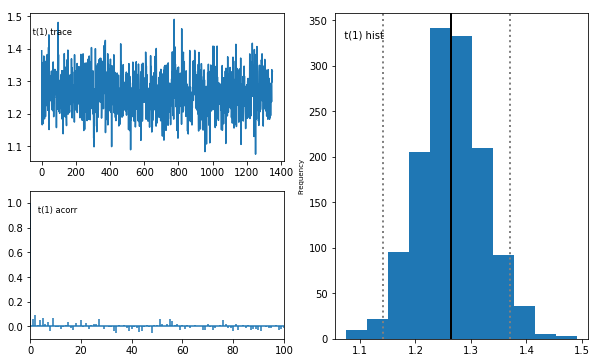

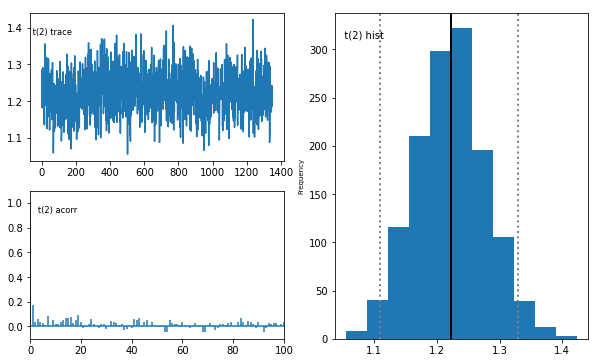

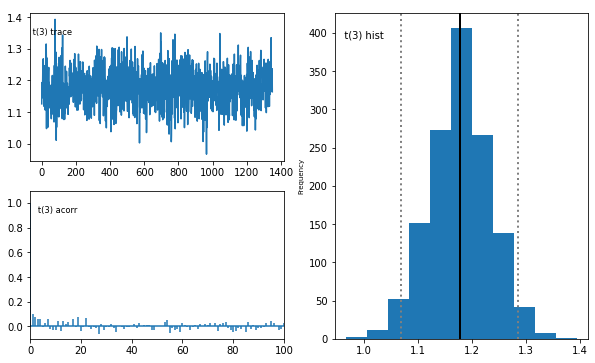

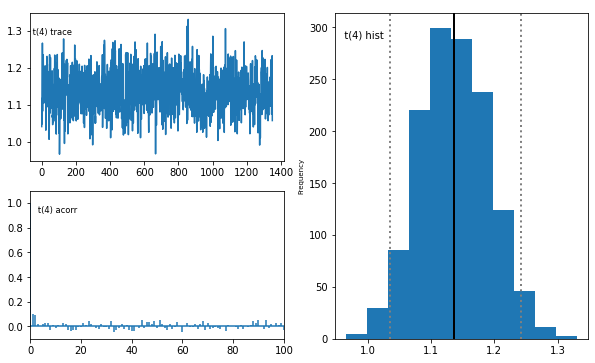

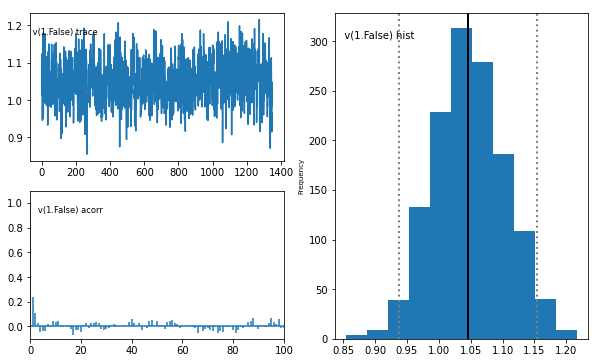

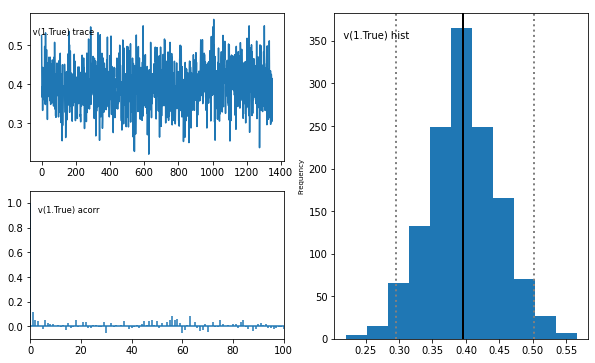

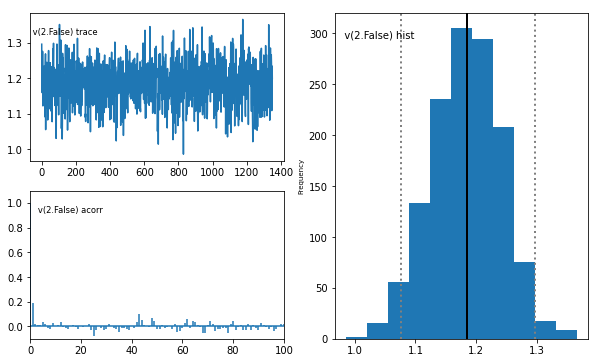

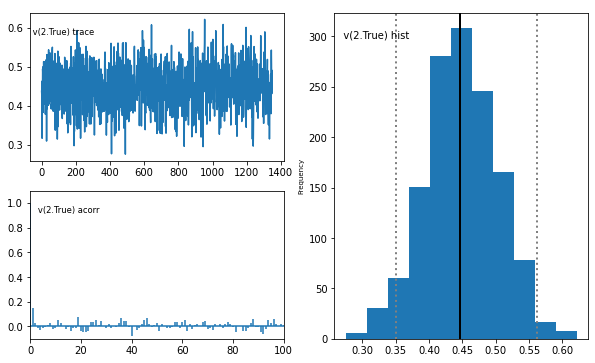

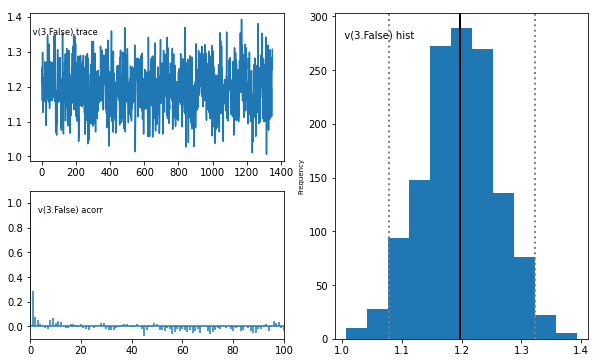

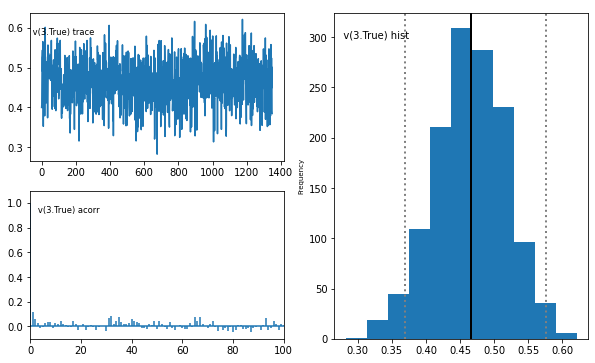

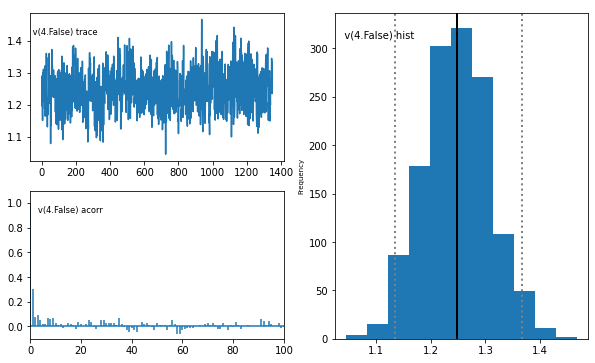

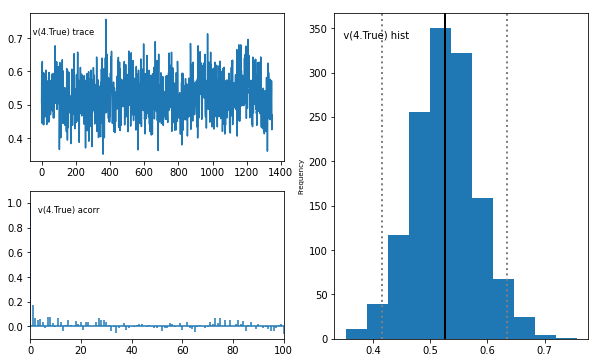

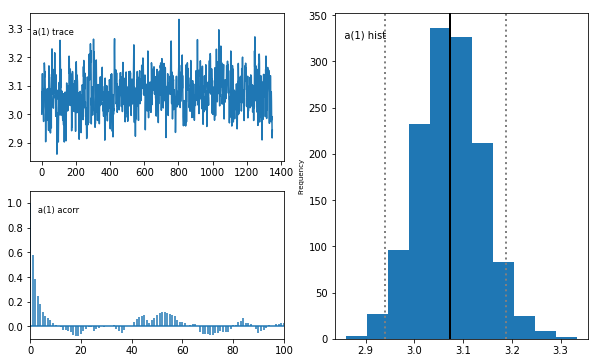

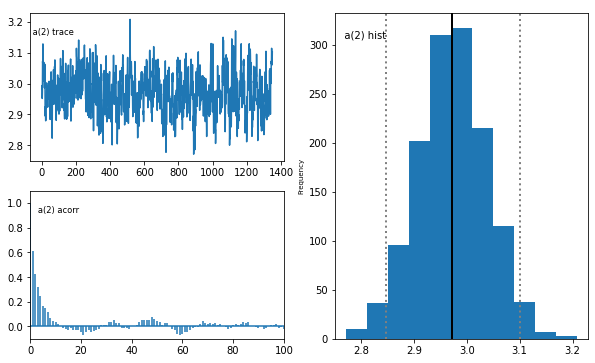

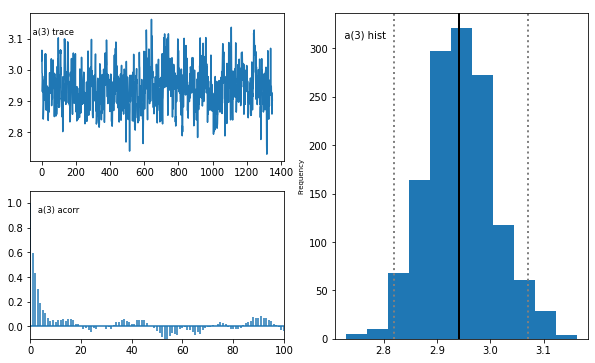

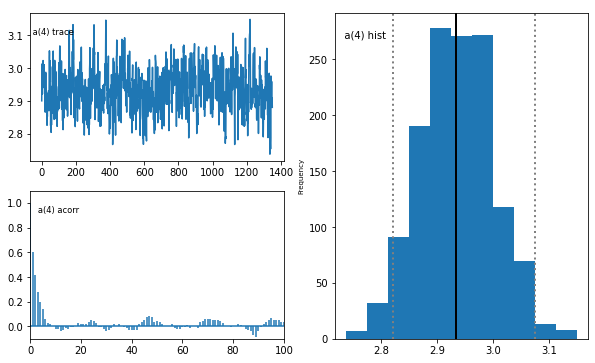

In [74]:
test_model.find_starting_values()
test_model.sample(samples, burn=samples/10, thin=2, dbname=os.path.join(cd, model_name, model_name + '_trace'), db='pickle')
test_model.save(model_name)
test_model.print_stats(model_name + '_dic.txt')
test_model_output = test_model.gen_stats()
test_model_output.to_csv(model_name + '_output.csv')

test_model.plot_posteriors(['t'], save=True)
test_model.plot_posteriors(['v'], save=True)
test_model.plot_posteriors(['a'], save=True)
# test_model.plot_posteriors(['z'], save=True)


# get traces to retrieve posterior distributions
test_model = hddm.load(model_name)
results = test_model.get_traces()
results.to_csv(model_name + '_within_traces.csv')


In [79]:
cd='/Users/ivar/Documents/mouserules/'
os.chdir(cd)

data = hddm.load_csv('mt_pilot.csv',delimiter = ',')


In [76]:
data

,mt_id,text,purpose,response,rt,MAD,AUC
0,id0001,0,0,0,2837.4178,271.422884,97178.5
1,id0002,1,0,1,4919.3217,312.125169,-6388.5
2,id0003,0,0,0,3159.0641,-122.641816,-49716.0
3,id0004,1,0,0,4572.7533,136.147984,45641.5
4,id0005,1,1,1,3341.4324,51.481562,12782.0
...,...,...,...,...,...,...,...
1418,id1527,1,1,1,1888.1823,186.302698,16323.5
1419,id1528,0,1,0,2044.4308,61.762332,25994.0
1420,id1529,1,0,1,1773.4171,-94.391307,-36243.5
1421,id1534,1,1,1,1846.5858,450.184481,157788.0


In [80]:
data.rename(columns = {'subject_nr':'subj_idx'}, inplace = True)
# filter
data['rt'] = data['rt']/1000
data = data[data['rt'] > 0.4]
data = data[data['rt'] < 6]
data

,subj_idx,text,purpose,response,rt,MAD,AUC
0,1,0,0,0,2.837418,271.422884,97178.5
1,1,1,0,1,4.919322,312.125169,-6388.5
2,1,0,0,0,3.159064,-122.641816,-49716.0
3,1,1,0,0,4.572753,136.147984,45641.5
4,1,1,1,1,3.341432,51.481562,12782.0
...,...,...,...,...,...,...,...
1418,8,1,1,1,1.888182,186.302698,16323.5
1419,8,0,1,0,2.044431,61.762332,25994.0
1420,8,1,0,1,1.773417,-94.391307,-36243.5
1421,8,1,1,1,1.846586,450.184481,157788.0


In [82]:
#%%
################
# MODEL 2
################
model_name = 'model1rules'
samples = 3000

#os.mkdir(cd + '/' + model_name)
os.chdir(cd + '/' + model_name)

test_model = hddm.HDDM(data, include=('v', 'a', 't', 'z'),  
                      depends_on={'v': ['text', 'purpose']}, 
                      p_outlier=.05)
                                   

/Users/ivar/opt/anaconda3/envs/pyHDDM/lib/python3.6/site-packages/scipy/optimize/optimize.py:2116: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)


 [-----------------100%-----------------] 3000 of 3000 complete in 393.0 secPlotting t
Plotting v(0.0)
Plotting v(0.1)
Plotting v(1.0)
Plotting v(1.1)
Plotting a


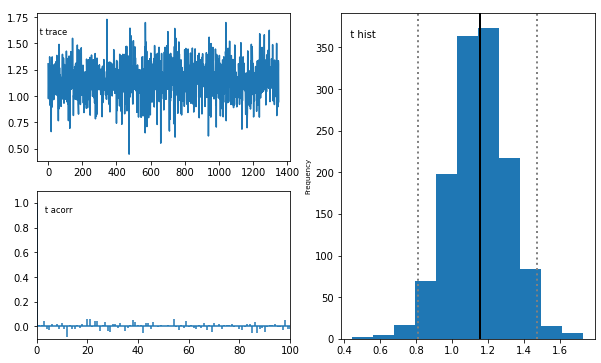

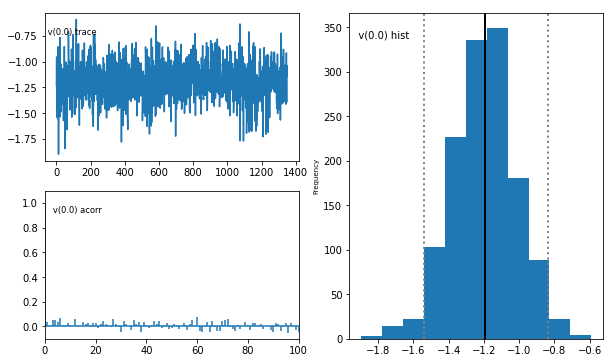

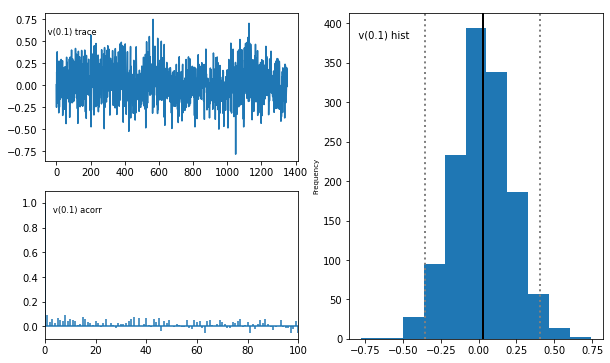

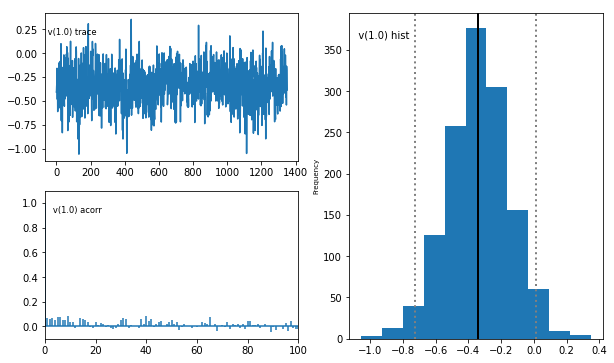

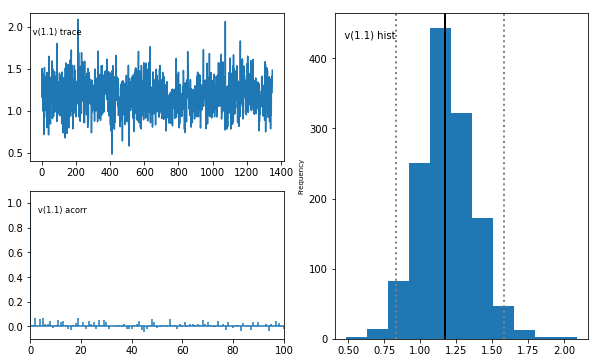

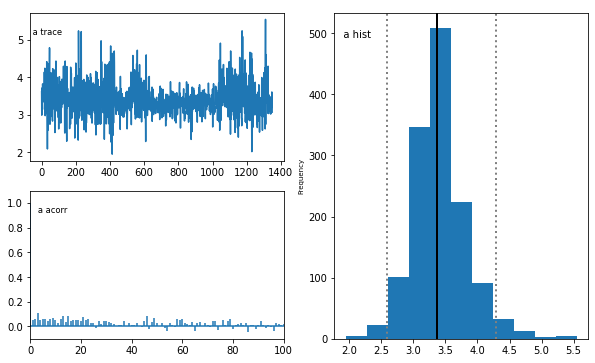

In [83]:
test_model.find_starting_values()
test_model.sample(samples, burn=samples/10, thin=2, dbname=os.path.join(cd, model_name, model_name + '_trace'), db='pickle')
test_model.save(model_name)
test_model.print_stats(model_name + '_dic.txt')
test_model_output = test_model.gen_stats()
test_model_output.to_csv(model_name + '_output.csv')

test_model.plot_posteriors(['t'], save=True)
test_model.plot_posteriors(['v'], save=True)
test_model.plot_posteriors(['a'], save=True)
# test_model.plot_posteriors(['z'], save=True)


# get traces to retrieve posterior distributions
test_model = hddm.load(model_name)
results = test_model.get_traces()
results.to_csv(model_name + '_within_traces.csv')


Plotting z


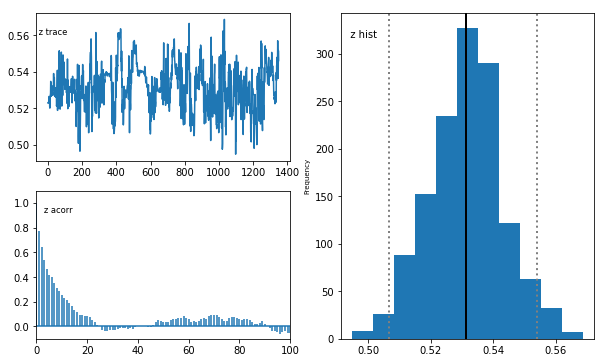

In [84]:
test_model.plot_posteriors(['z'], save=True)